In [22]:
#!/usr/bin/env python3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Analyse descriptive du dataset final

## 1. Présentation du dataset final

In [23]:
Dataset_final = pd.read_csv("data_final.csv", sep=',', decimal=',')

In [24]:
Dataset_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 384 entries, 0 to 383
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   etat             384 non-null    str  
 1   matiere          384 non-null    str  
 2   couleur          384 non-null    str  
 3   categorie        384 non-null    str  
 4   likes            384 non-null    str  
 5   prix             384 non-null    str  
 6   prix_total       384 non-null    str  
 7   collection       384 non-null    str  
 8   prix_moyen_zara  384 non-null    str  
 9   decote           384 non-null    str  
dtypes: str(10)
memory usage: 30.1 KB


# 2. Analyse des variables quantitatives

In [25]:
colonnes_num = ["likes", "prix", "prix_total", "prix_moyen_zara", "decote"]

Dataset_final[colonnes_num].describe()

,likes,prix,prix_total,prix_moyen_zara,decote
count,384,384,384,384,384
unique,83,44,82,67,267
top,8.0,5.0,5.95,22.95,0.8748435544430538
freq,23,57,31,28,6


# 3. Analyse des variables qualitatives

In [26]:
# Analyse descriptive complète des variables qualitatives

colonnes_qualitatives = [
    "categorie",
    "etat",
    "matiere",
    "couleur",
    "collection"
]

for col in colonnes_qualitatives:
    print(f"\n===== {col.upper()} =====")
    print(Dataset_final[col].value_counts())


===== CATEGORIE =====
categorie
hauts et t-shirts                   100
pantalons et leggings                47
manteaux et vestes                   36
jeans                                34
robes                                31
sweats et sweats à capuche           27
chaussures                           27
blazers et tailleurs                 24
jupes                                13
accessoires                           9
combinaisons et combishorts           8
shorts                                8
vêtements de sport                    6
costumes et tenues particulières      4
autres                                3
jupes-shorts                          2
maillots de bain                      2
lingerie et pyjamas                   2
sacs                                  1
Name: count, dtype: int64

===== ETAT =====
etat
très bon état          221
neuf sans étiquette     94
neuf avec étiquette     51
bon état                18
Name: count, dtype: int64

===== MATIERE =====
mat

### Filtrage des groupes peu représentés

In [27]:
# ===== FILTRAGE DES GROUPES AVEC AU MOINS 10 OBSERVATIONS =====

# Catégories fréquentes
categories_valides = Dataset_final["categorie"].value_counts()
categories_valides = categories_valides[categories_valides >= 10].index

# Matières fréquentes
matieres_valides = Dataset_final["matiere"].value_counts()
matieres_valides = matieres_valides[matieres_valides >= 10].index

# Couleurs fréquentes
couleurs_valides = Dataset_final["couleur"].value_counts()
couleurs_valides = couleurs_valides[couleurs_valides >= 10].index

# États fréquents
etats_valides = Dataset_final["etat"].value_counts()
etats_valides = etats_valides[etats_valides >= 10].index

# Dataset filtré
Dataset_filtre = Dataset_final[
    (Dataset_final["categorie"].isin(categories_valides)) &
    (Dataset_final["matiere"].isin(matieres_valides)) &
    (Dataset_final["couleur"].isin(couleurs_valides)) &
    (Dataset_final["etat"].isin(etats_valides))
]

print(Dataset_filtre.shape)

(336, 10)


# 4. Visualisations graphiques

### distribution des prix 

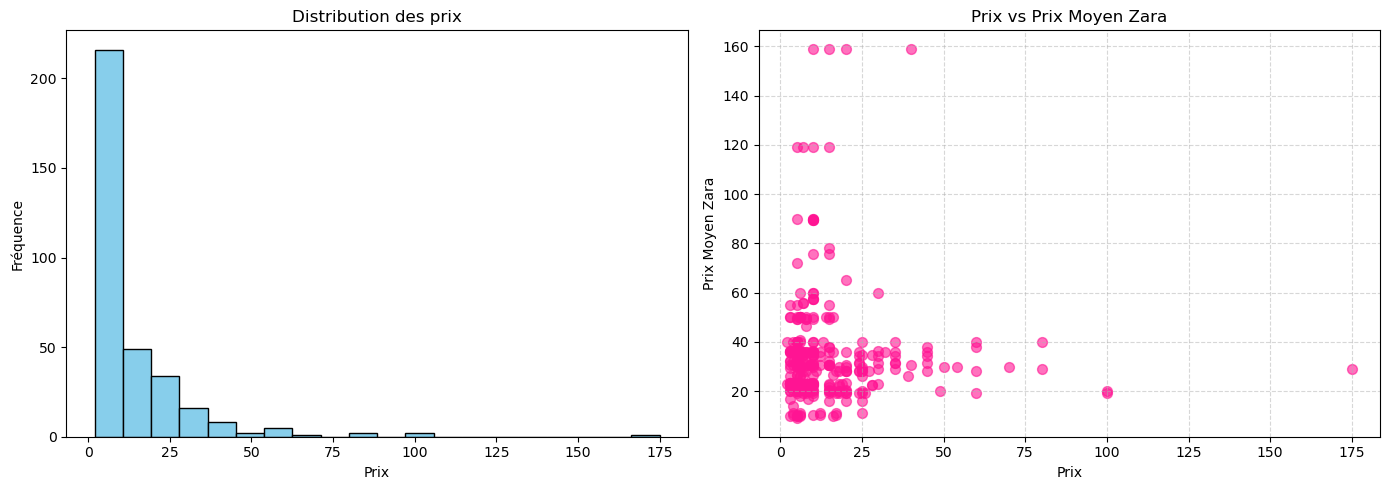

In [28]:
# Conversion en valeurs numériques
Dataset_filtre["prix"] = pd.to_numeric(Dataset_filtre["prix"], errors="coerce")
Dataset_filtre["prix_moyen_zara"] = pd.to_numeric(Dataset_filtre["prix_moyen_zara"], errors="coerce")

# Création de la figure
fig, ax = plt.subplots(1, 2, figsize=(14,5))

# Histogramme
ax[0].hist(
    Dataset_filtre["prix"].dropna(),
    bins=20,
    color="skyblue",
    edgecolor="black"
)

ax[0].set_title("Distribution des prix")
ax[0].set_xlabel("Prix")
ax[0].set_ylabel("Fréquence")

# Vrai nuage de points
ax[1].scatter(
    Dataset_filtre["prix"],
    Dataset_filtre["prix_moyen_zara"],
    alpha=0.6,
    s=50,
    color="deeppink"
)

ax[1].set_title("Prix vs Prix Moyen Zara")
ax[1].set_xlabel("Prix")
ax[1].set_ylabel("Prix Moyen Zara")

ax[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

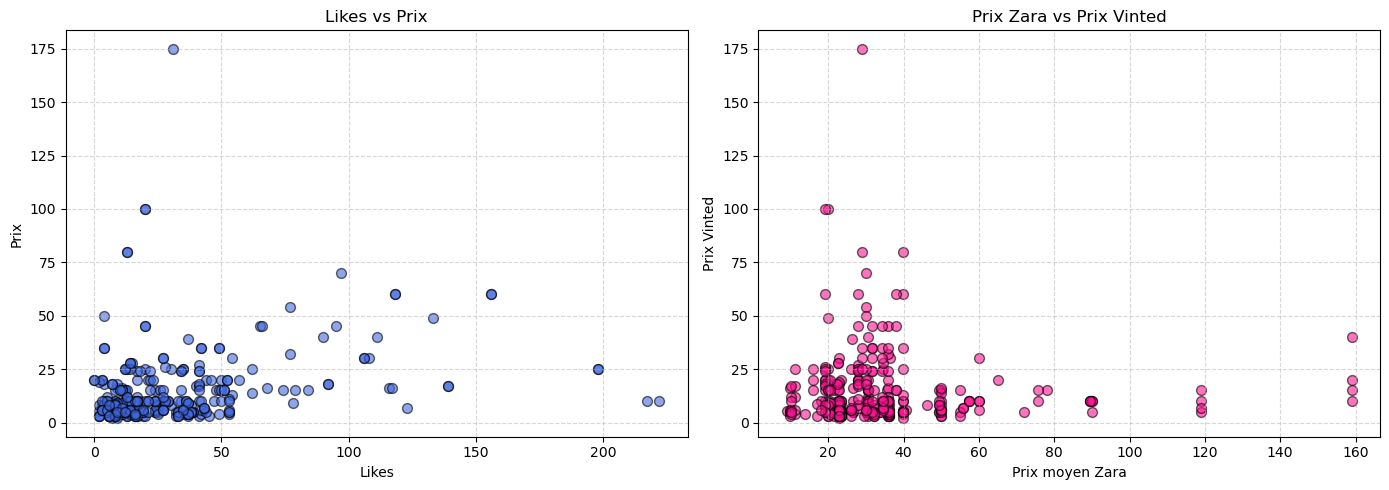

In [29]:
# Conversion en numérique
Dataset_filtre["likes"] = pd.to_numeric(Dataset_filtre["likes"], errors="coerce")
Dataset_filtre["prix"] = pd.to_numeric(Dataset_filtre["prix"], errors="coerce")
Dataset_filtre["prix_moyen_zara"] = pd.to_numeric(Dataset_filtre["prix_moyen_zara"], errors="coerce")

# Création de la figure avec 2 graphiques
fig, ax = plt.subplots(1, 2, figsize=(14,5))

# Likes vs Prix
ax[0].scatter(
    Dataset_filtre["likes"],
    Dataset_filtre["prix"],
    alpha=0.6,
    s=50,
    color="royalblue",
    edgecolors="black"
)

ax[0].set_title("Likes vs Prix")
ax[0].set_xlabel("Likes")
ax[0].set_ylabel("Prix")
ax[0].grid(True, linestyle="--", alpha=0.5)

# Prix moyen Zara vs Prix
ax[1].scatter(
    Dataset_filtre["prix_moyen_zara"],
    Dataset_filtre["prix"],
    alpha=0.6,
    s=50,
    color="deeppink",
    edgecolors="black"
)

ax[1].set_title("Prix Zara vs Prix Vinted")
ax[1].set_xlabel("Prix moyen Zara")
ax[1].set_ylabel("Prix Vinted")
ax[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# 5.Analyses  de la decote 

### Prix  décotes moyennes par catégorie et état et matiere

IndexError: index 2 is out of bounds for axis 1 with size 2

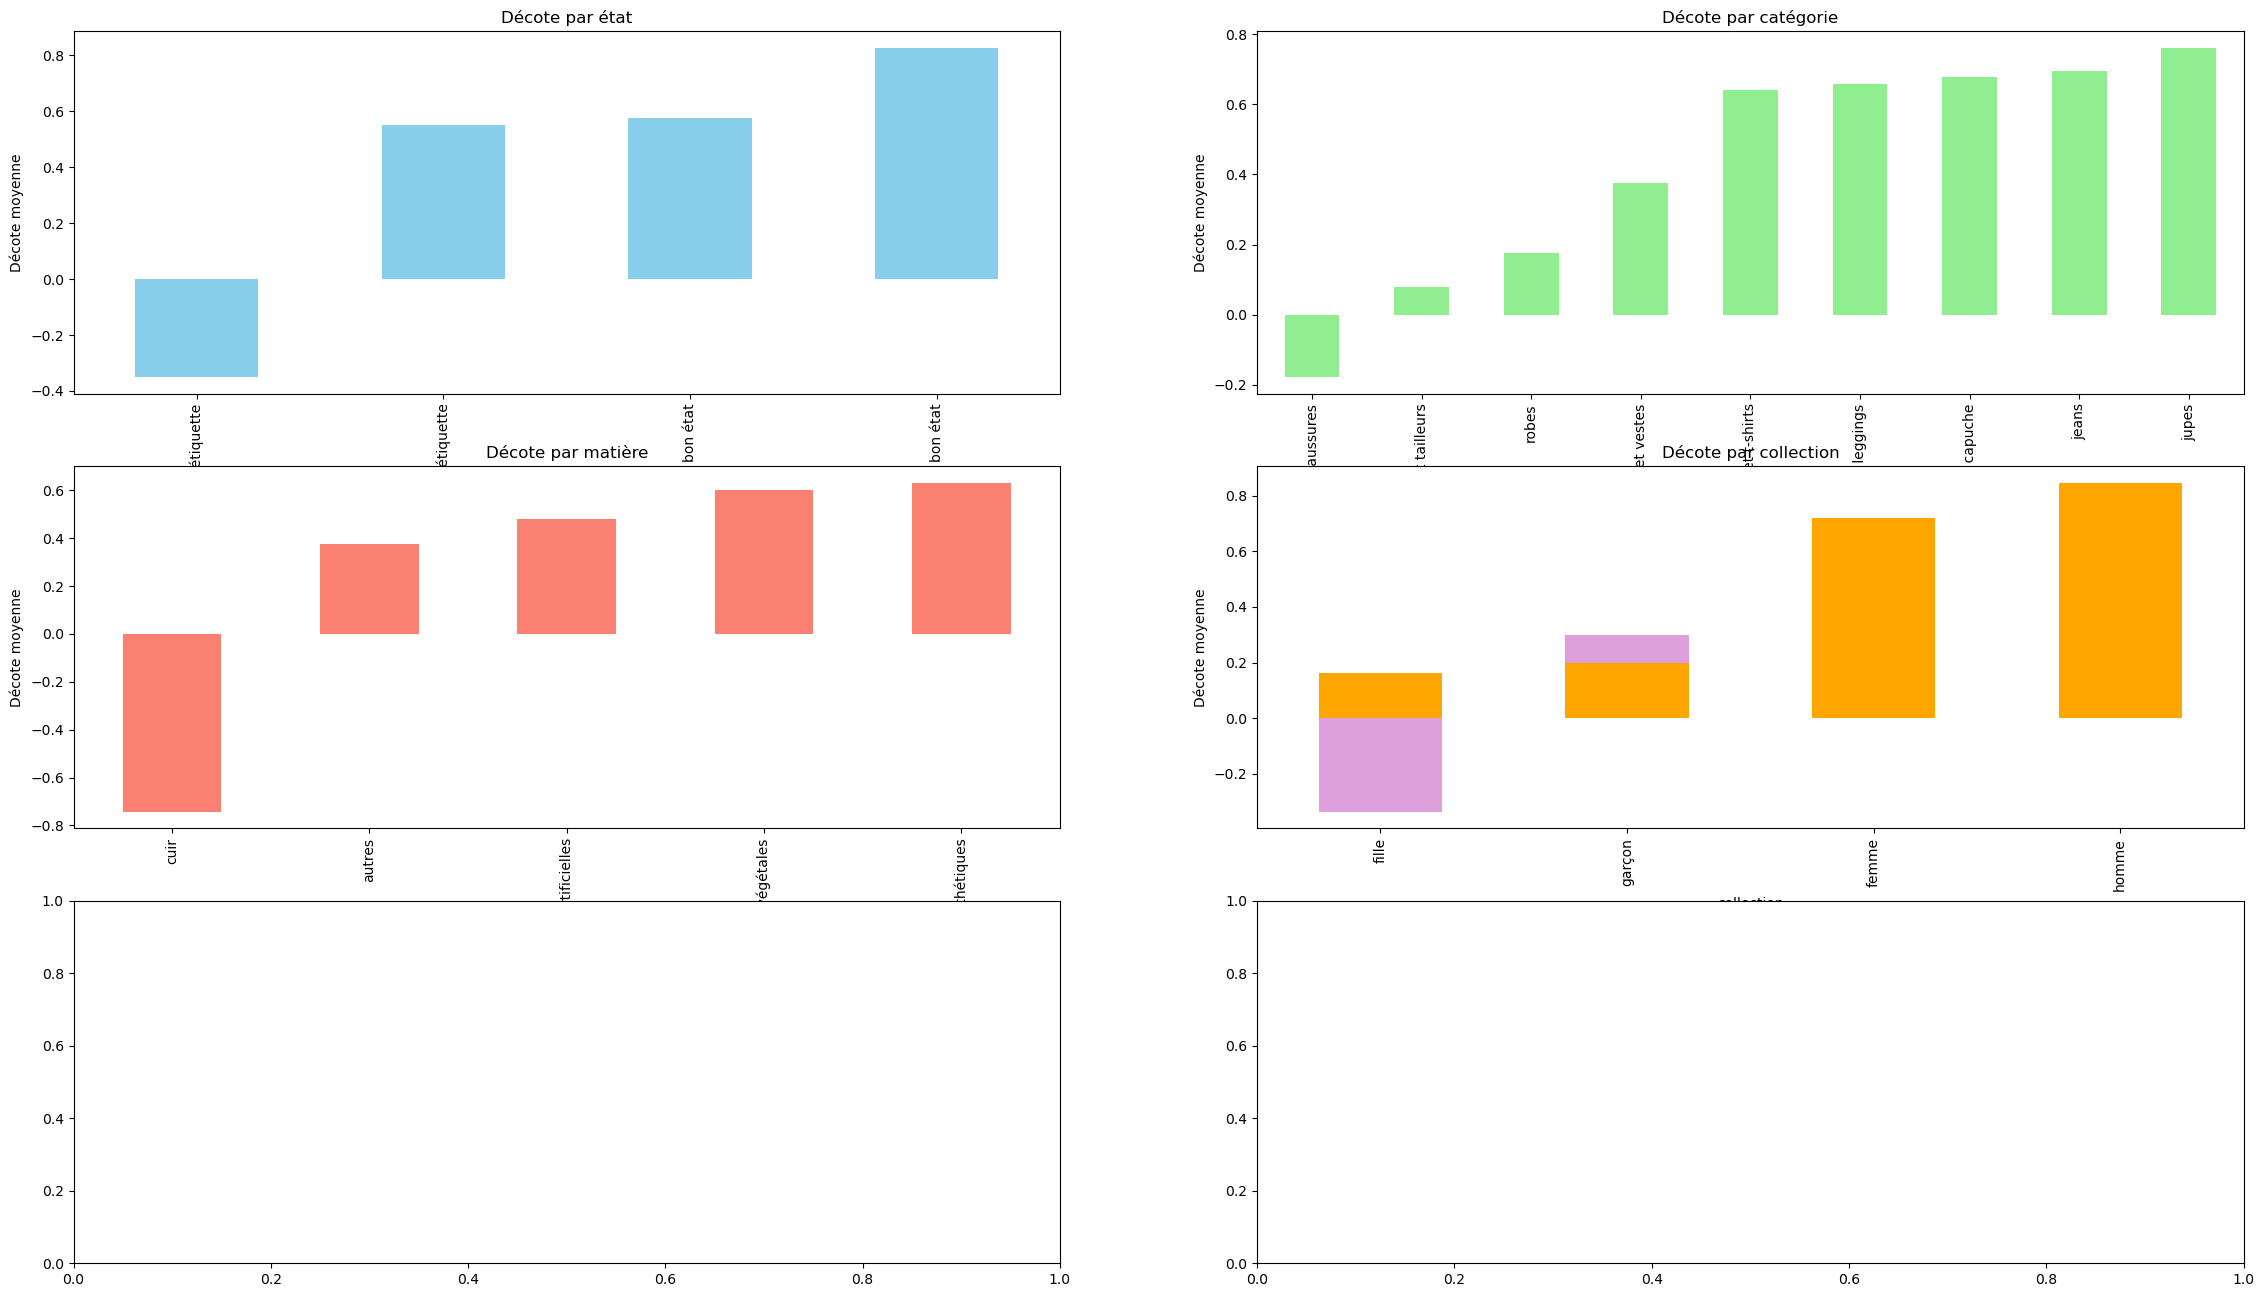

In [ ]:
fig, ax = plt.subplots(3, 2, figsize=(28,16))

# Décote moyenne par état
# ensure 'decote' is numeric before aggregation
Dataset_filtre["decote"] = pd.to_numeric(Dataset_filtre["decote"], errors="coerce")

Dataset_filtre.groupby("etat")["decote"].mean().sort_values().plot(
    kind="bar",
    ax=ax[0,0],
    color="skyblue"
)

ax[0,0].set_title("Décote par état")
ax[0,0].set_ylabel("Décote moyenne")

# Décote moyenne par catégorie
Dataset_filtre.groupby("categorie")["decote"].mean().sort_values().plot(
    kind="bar",
    ax=ax[0,1],
    color="lightgreen"
)

ax[0,1].set_title("Décote par catégorie")
ax[0,1].set_ylabel("Décote moyenne")

# Décote moyenne par matière
Dataset_filtre.groupby("matiere")["decote"].mean().sort_values().plot(
    kind="bar",
    ax=ax[1,0],
    color="salmon"
)

ax[1,0].set_title("Décote par matière")
ax[1,0].set_ylabel("Décote moyenne")

# Décote moyenne par couleur
Dataset_filtre.groupby("couleur")["decote"].mean().sort_values().plot(
    kind="bar",
    ax=ax[1,1],
    color="plum"
)

ax[1,1].set_title("Décote par couleur")
ax[1,1].set_ylabel("Décote moyenne")

# Décote moyenne par collection
Dataset_filtre.groupby("collection")["decote"].mean().sort_values().plot(
    kind="bar",
    ax=ax[1,1],
    color="orange"
)

ax[1,1].set_title("Décote par collection")
ax[1,1].set_ylabel("Décote moyenne")

# Décote moyenne par collection
Dataset_filtre.groupby("collection")["decote"].mean().sort_values().plot(
    kind="bar",
    ax=ax[2,0],
    color="orange"
)

ax[2,0].set_title("Décote par collection")
ax[2,0].set_ylabel("Décote moyenne")

fig.delaxes(ax[2,1])
for axes in ax.flat:
 axes.tick_params(axis='x', rotation=60)
plt.tight_layout()
plt.show()

# 6. Corrélations

### Heatmap des corrélations

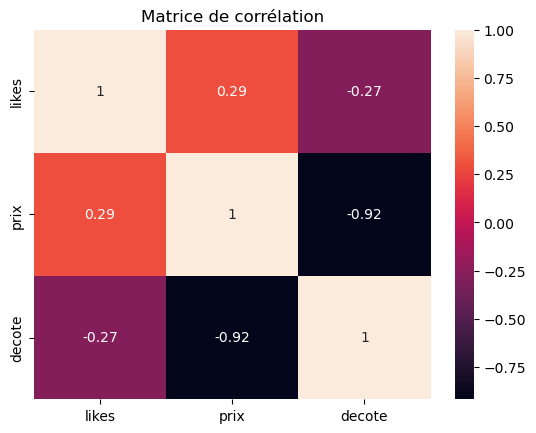

In [ ]:

sns.heatmap(
    Dataset_filtre[
        [
            "likes",
            "prix",
            "decote"
        ]
    ].corr(),
    annot=True
)

plt.title("Matrice de corrélation")

plt.show()